#Palmer Penguins Mini-Project

In [34]:
# imports

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Data Loading using Pandas


In [35]:
uploaded = files.upload()

Saving Palmer Penguins Dataset.csv to Palmer Penguins Dataset (1).csv


In [71]:
df = pd.read_csv('Palmer Penguins Dataset.csv')

print(f'Size of dataset: {df.shape[0]} penguins x  {df.shape[1]} columns')

print("\nFirst 5 rows:")
display(df.head())

print("\nSummary: columns names, nulls and data types\n")
print(df.info())

Size of dataset: 344 penguins x  8 columns

First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007



Summary: columns names, nulls and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB
None


#Basic Data Cleaning


In [72]:
# == Check duplicates==

dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

#There are no duplicate records in the dataframe


Duplicate rows: 0


In [73]:
# == Check missing values ==

missing_counts = df.isnull().sum()
missing_pct = ((missing_counts / len(df)) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
}).query("`Missing Count` > 0").sort_values(by='Missing %', ascending=False)

display(missing_df)

,Missing Count,Missing %
sex,11,3.2
bill_length_mm,2,0.6
bill_depth_mm,2,0.6
flipper_length_mm,2,0.6
body_mass_g,2,0.6


In [74]:
# Strategy for replacing missing values with:

# mode value if the variable is categorical
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])


# median value if the variable is numerical
# 	bill_length_mm 44.450000
# 	bill_depth_mm  17.300000
#   flipper_length_mm 197.000000
#   body_mass_g	 4050.000000

numeric_cols = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# == Final Check on missing values ==
print(df.isnull().sum())

print(f'\nThere are no missing values in the dataframe')

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

There are no missing values in the dataframe


In [75]:
# -----------------------------
# Convertion Data Types
# -----------------------------

# Convert to categorical columns
categorical_cols = ['species', 'island', 'sex', 'year']
df[categorical_cols] = df[categorical_cols].astype('category')


In [76]:
#check data types
df.dtypes

,0
species,category
island,category
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,category
year,category


#Exploratory Data Analysis (EDA)

Summarize the key statistics of the dataset.

Identify unique values, ranges, and distribution of data.

In [77]:
# ===========================================
# Check distributions
# ===========================================

# ---- summary statistics ----
display(df.describe())
display(df.describe(include='category'))

# ---- categorical overview ----

print("\nSpecies counts:")
print(df["species"].value_counts())

print("\nIsland counts:")
print(df["island"].value_counts())

print("\nSex counts:")
print(df["sex"].value_counts())

print("\nYear counts:")
print(df["year"].value_counts())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,344.000000,344.000000,344.000000,344.000000
mean,43.925000,17.152035,200.892442,4200.872093
std,5.443792,1.969060,14.023826,799.696532
min,32.100000,13.100000,172.000000,2700.000000
25%,39.275000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


,species,island,sex,year
count,344,344,344,344
unique,3,3,2,3
top,Adelie,Biscoe,male,2009
freq,152,168,179,120



Species counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Island counts:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Sex counts:
sex
male      179
female    165
Name: count, dtype: int64

Year counts:
year
2009    120
2008    114
2007    110
Name: count, dtype: int64


#Visualizations

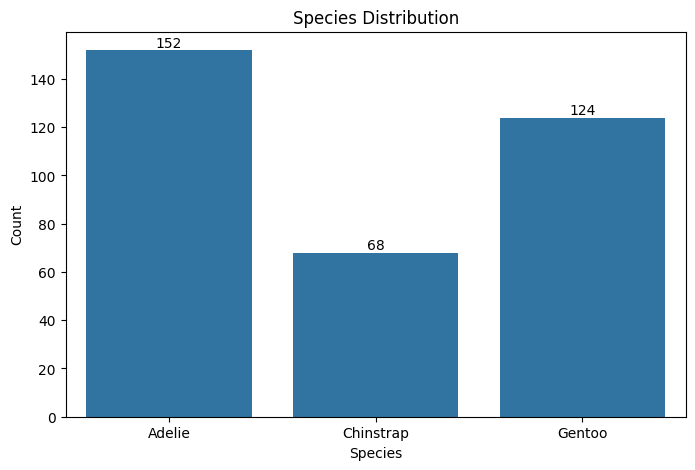

In [79]:
# Species Distribution: Use a bar chart to show the distribution of penguin species.

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='species')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

This dataset evaluates 3 penguin species: Adélie, Gentoo, and Chinstrap, with Adélie being slightly dominant.


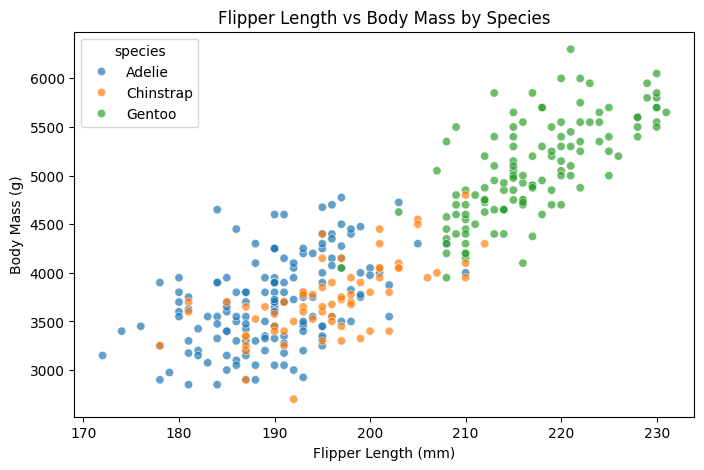

In [78]:
# Flipper Length vs. Body Mass: Create a scatter plot to analyze the relationship between flipper length and body mass, color-coded by species.

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    alpha=0.7
)

plt.title("Flipper Length vs Body Mass, by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()


Clear positive relationship.

The species form well-separated clusters.

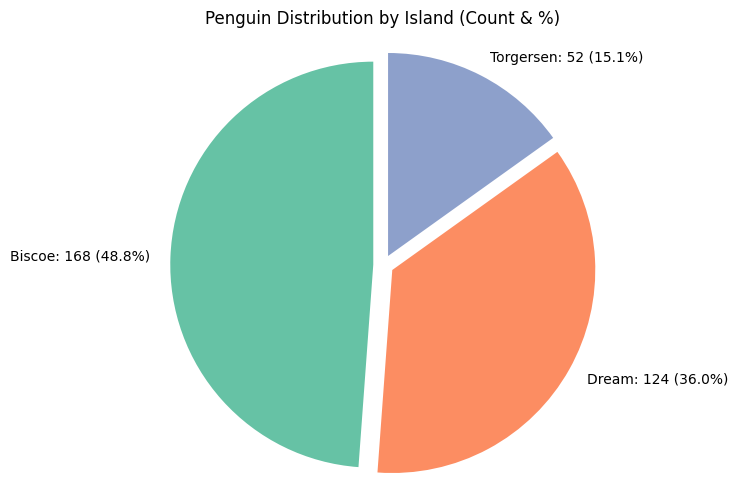

In [57]:
# Island Distribution: Visualize the count of penguins on each island using a pie chart.

island_counts = df['island'].value_counts()
total = island_counts.sum()

plt.figure(figsize=(6,6))
plt.pie(
    island_counts,
    labels=[f"{idx}: {count} ({count/total:.1%})" for idx, count in zip(island_counts.index, island_counts)],
    startangle=90,
    colors=['#66c2a5','#fc8d62','#8da0cb'],
    explode=[0.05]*len(island_counts)
)
plt.title("Penguin Distribution by Island (Count & %)")
plt.axis('equal')
plt.show()

Almost half of the penguin sample is counted on Biscoe Island

(0.0, 100.0)

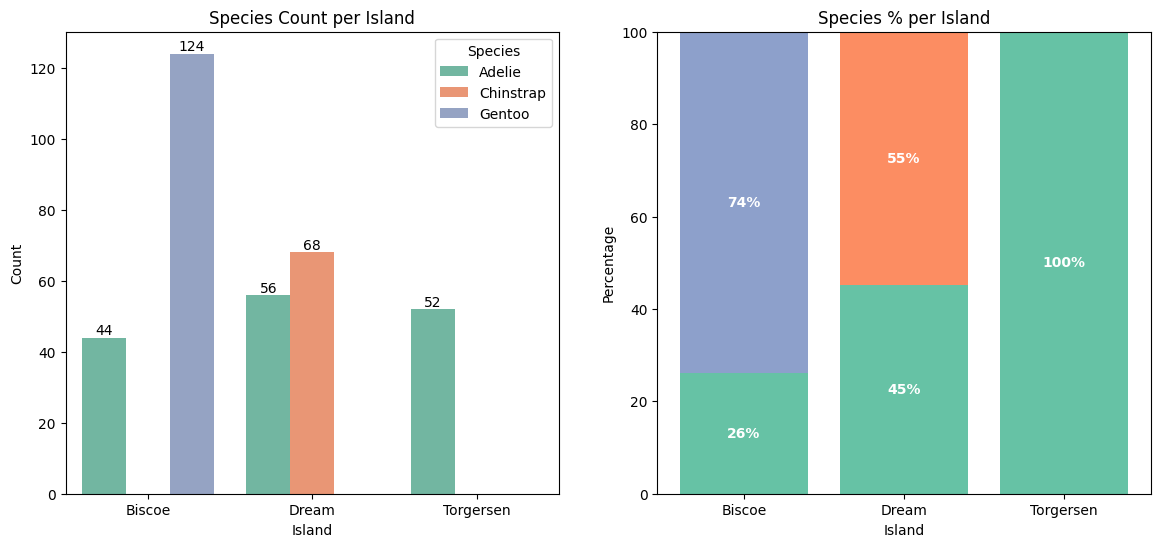

In [93]:
# Extra: Species distribution by island

fig, axes = plt.subplots(1, 2, figsize=(14,6))

species_colors = {'Adelie':'#66c2a5', 'Chinstrap':'#fc8d62', 'Gentoo':'#8da0cb'}

# -------------------------------
# Countplot (Quantity)
# -------------------------------
sns.countplot(
    data=df,
    x='island',
    hue='species',
    palette=species_colors,
    ax=axes[0]
)

axes[0].set_title("Species Count per Island")
axes[0].set_xlabel("Island")
axes[0].set_ylabel("Count")
axes[0].legend(title="Species")

for container in axes[0].containers:
    axes[0].bar_label(container)

# -------------------------------
# Stacked Bar Chart (%)
# -------------------------------
island_species = df.groupby(['island','species'], observed=True).size().unstack(fill_value=0)
island_species_prop = island_species.div(island_species.sum(axis=1), axis=0)

bottom = np.zeros(len(island_species_prop))
for sp in ['Adelie','Chinstrap','Gentoo']:
    axes[1].bar(
        island_species_prop.index,
        island_species_prop[sp]*100,
        bottom=bottom,
        color=species_colors[sp],
        label=sp
    )
    bottom += island_species_prop[sp]*100

for i, isl in enumerate(island_species_prop.index):
    cum_bottom = 0
    for sp in ['Adelie','Chinstrap','Gentoo']:
        height = island_species_prop.loc[isl, sp]*100
        if height > 0:
            axes[1].text(
                i,
                cum_bottom + height/2,
                f"{height:.0f}%",
                ha='center',
                va='center',
                color='white',
                fontweight='bold'
            )
            cum_bottom += height

axes[1].set_title("Species % per Island")
axes[1].set_xlabel("Island")
axes[1].set_ylabel("Percentage")
axes[1].set_ylim(0,100)

- Biscoe: 26% Adelie + 74% Gentoo
- Dream: 45% Adelie + 55% Chinstrap
- Torgersen: 100% Adelie

Each species has its ecological preferences, depending on the island.

Text(0.5, 0, 'Species')

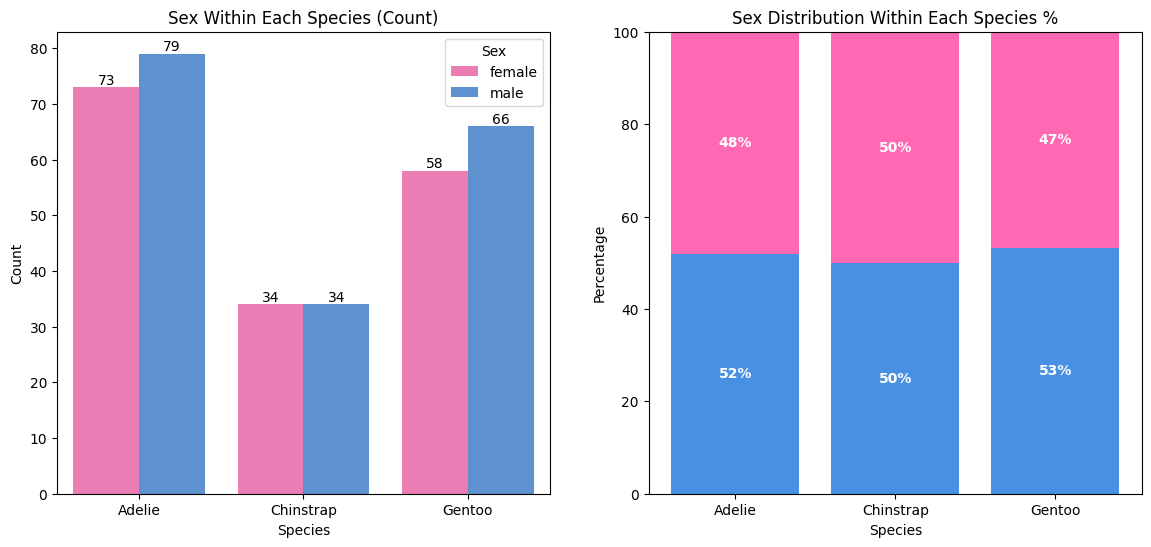

In [94]:
# Sex Distribution within Species: Create grouped bar charts showing the distribution of sex within each penguin species.

sex_colors = {'male': '#4A90E2', 'female': '#FF69B4'}

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# -------------------------------
#  Countplot (Quantity)
# -------------------------------
ax1 = axes[0]
sns.countplot(
    data=df,
    x='species',
    hue='sex',
    palette=sex_colors,
    ax=ax1
)

for container in ax1.containers:
    ax1.bar_label(container)

ax1.set_title("Sex Within Each Species (Count)")
ax1.set_xlabel("Species")
ax1.set_ylabel("Count")
ax1.legend(title="Sex")

# -------------------------------
# Stacked Bar Chart (%)
# -------------------------------
prop_df = df.groupby(['species','sex'], observed=True).size().unstack(fill_value=0)
prop_df = prop_df.div(prop_df.sum(axis=1), axis=0)

ax2 = axes[1]
bottom = np.zeros(len(prop_df))
for sex in ['male','female']:
    ax2.bar(
        prop_df.index,
        prop_df[sex]*100,
        bottom=bottom,
        color=sex_colors[sex],
        label=sex
    )
    bottom += prop_df[sex]*100

for i, species in enumerate(prop_df.index):
    cum_bottom = 0
    for sex in ['male','female']:
        height = prop_df.loc[species, sex]*100
        if height > 0:
            ax2.text(
                i,
                cum_bottom + height/2,
                f"{height:.0f}%",
                ha='center',
                va='center',
                color='white',
                fontweight='bold'
            )
            cum_bottom += height

ax2.set_title("Sex Distribution Within Each Species %")
ax2.set_ylabel("Percentage")
ax2.set_ylim(0,100)
ax2.set_xlabel("Species")

Constant Sex Distribution across the 3 species

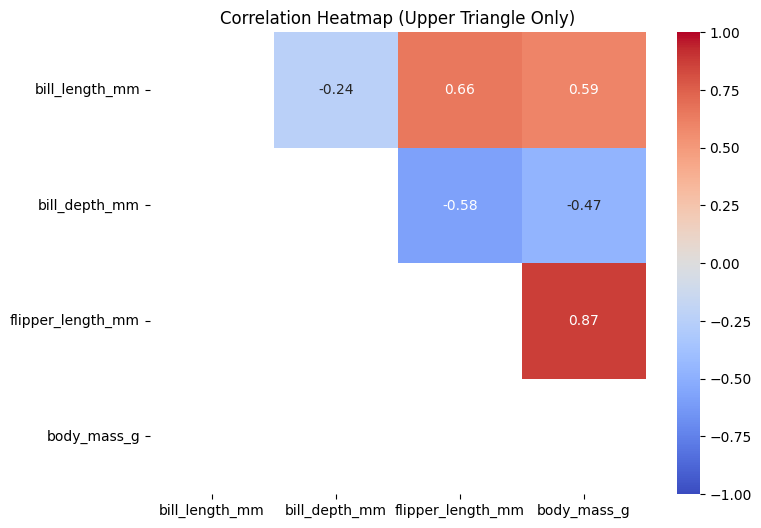

In [95]:
# Heatmap of Correlations: Plot a heatmap to visualize the correlations between numerical variables.

plt.figure(figsize=(8,6))

numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    mask= np.tril(np.ones_like(correlation_matrix, dtype=bool)),   # upper half (upper triangle)
    vmin=-1, vmax=1
)

plt.title("Correlation Heatmap (Upper Triangle Only)")
plt.show()



Flipper and body mass → strong positive correlation of 0.87

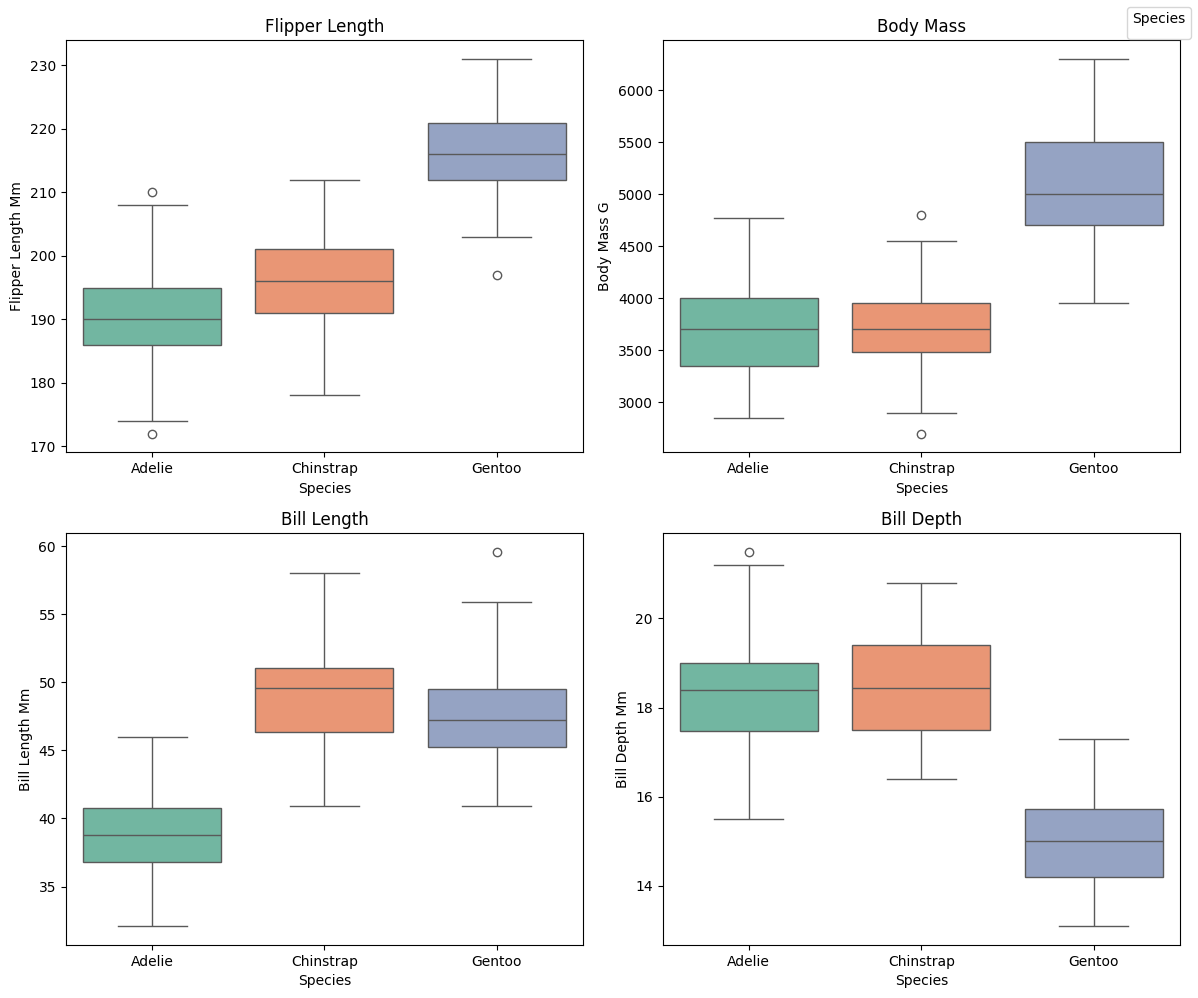

In [98]:
# Boxplots for Measurements: Generate boxplots for flipper length, body mass, and bill measurements, segmented by species.

fig, axes = plt.subplots(2, 2, figsize=(12,10))

species_colors = {'Adelie':'#66c2a5', 'Chinstrap':'#fc8d62', 'Gentoo':'#8da0cb'}
measurements = ['flipper_length_mm', 'body_mass_g', 'bill_length_mm', 'bill_depth_mm']
titles = ['Flipper Length', 'Body Mass', 'Bill Length', 'Bill Depth']

for i, col in enumerate(measurements):
    sns.boxplot(
        data=df,
        x='species',
        y=col,
        hue='species',
        palette=species_colors,
        ax=axes[i//2, i%2],
        dodge=False,
        legend=False
    )
    axes[i//2, i%2].set_title(titles[i])
    axes[i//2, i%2].set_xlabel("Species")
    axes[i//2, i%2].set_ylabel(col.replace("_", " ").title())

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, title='Species', loc='upper right')

plt.tight_layout()
plt.show()

Gentoo are typically significantly larger (flipper and body mass).

Adelie and Chinstrap differ more regarding bill characteristics.

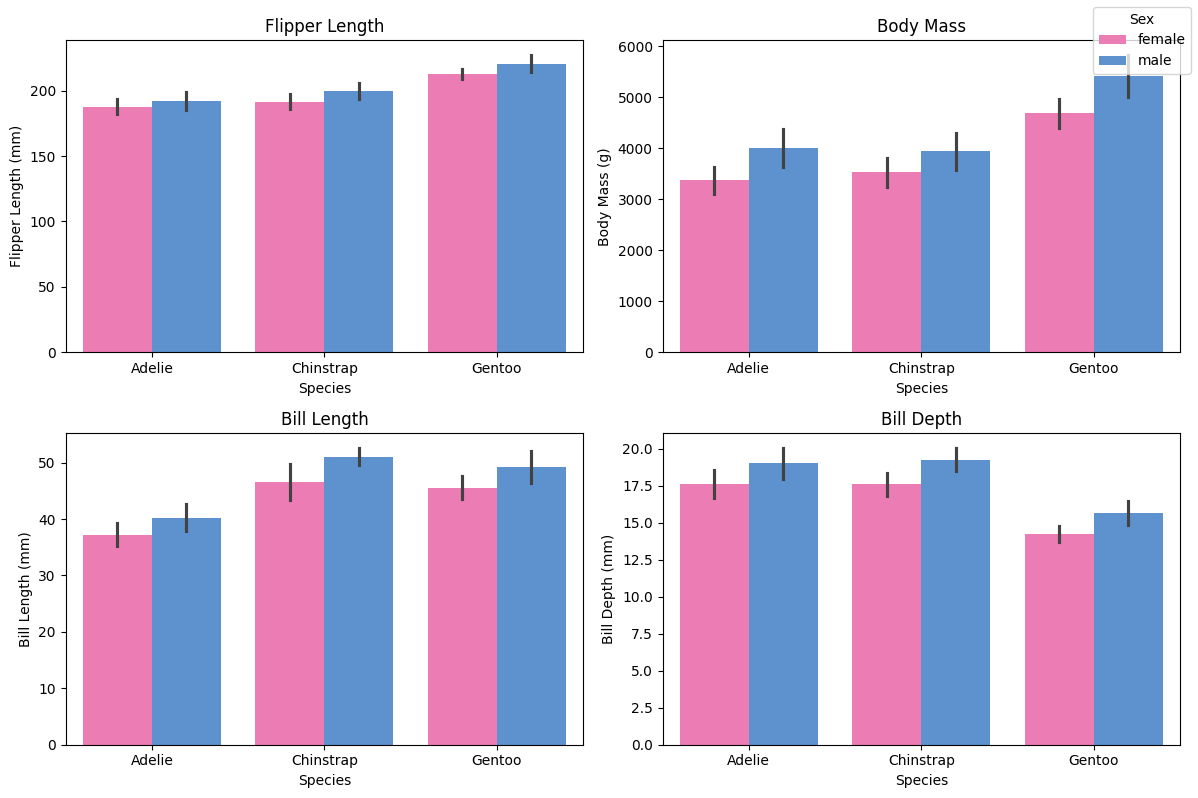

In [99]:
# Extra: Comparison by Species & Sex

fig, axes = plt.subplots(2, 2, figsize=(12,8))
sex_colors = {'male':'#4A90E2', 'female':'#FF69B4'}

# Flipper Length
sns.barplot(
    data=df,
    x='species',
    y='flipper_length_mm',
    hue='sex',
    palette=sex_colors,
    errorbar='sd',  # desviación estándar
    ax=axes[0,0]
)
axes[0,0].set_title("Flipper Length")
axes[0,0].set_ylabel("Flipper Length (mm)")
axes[0,0].set_xlabel("Species")


#  Body Mass
sns.barplot(
    data=df,
    x='species',
    y='body_mass_g',
    hue='sex',
    palette=sex_colors,
    errorbar='sd',
    ax=axes[0,1]
)
axes[0,1].set_title("Body Mass")
axes[0,1].set_ylabel("Body Mass (g)")
axes[0,1].set_xlabel("Species")


# Bill Length
sns.barplot(
    data=df,
    x='species',
    y='bill_length_mm',
    hue='sex',
    palette=sex_colors,
    errorbar='sd',
    ax=axes[1,0]
)
axes[1,0].set_title("Bill Length")
axes[1,0].set_ylabel("Bill Length (mm)")
axes[1,0].set_xlabel("Species")


# Bill Depth
sns.barplot(
    data=df,
    x='species',
    y='bill_depth_mm',
    hue='sex',
    palette=sex_colors,
    errorbar='sd',
    ax=axes[1,1]
)
axes[1,1].set_title("Bill Depth")
axes[1,1].set_ylabel("Bill Depth (mm)")
axes[1,1].set_xlabel("Species")

#unique adjusted legend, outside of the subplots
handles, labels = axes[1,1].get_legend_handles_labels()
fig.legend(handles, labels, title='Sex', loc='upper right')

for ax in axes.flatten():
    ax.get_legend().remove()

plt.tight_layout()
plt.show()

Sexual dimorphism present in all species (males larger): It is clear that in all measurements related to flipper, body mass and bill that males are more "voluminous" than females.

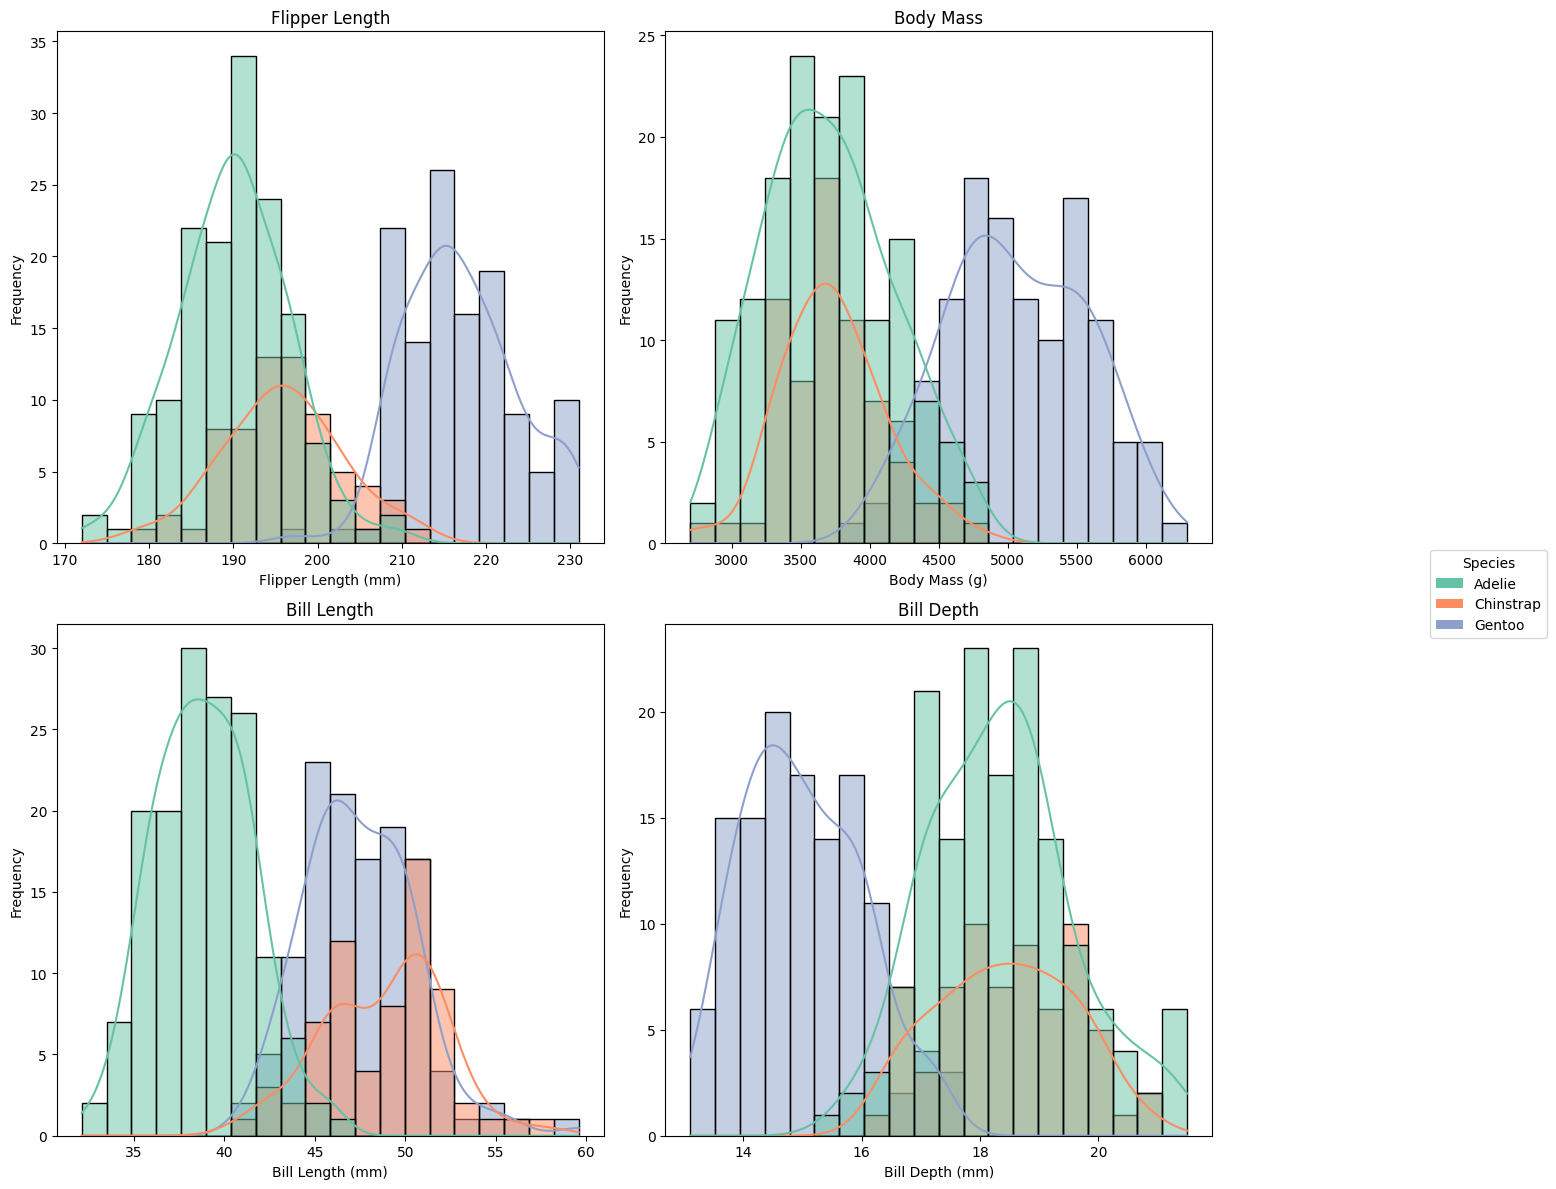

In [110]:
# Histograms of Measurements: Create histograms to show the distribution of key measurements (bill length, bill depth, flipper length).

fig, axes = plt.subplots(2, 2, figsize=(14,12))

species_colors = {'Adelie':'#66c2a5',
                  'Chinstrap':'#fc8d62',
                  'Gentoo':'#8da0cb'}

plots = [
    ('flipper_length_mm', "Flipper Length", "Flipper Length (mm)"),
    ('body_mass_g', "Body Mass", "Body Mass (g)"),
    ('bill_length_mm', "Bill Length", "Bill Length (mm)"),
    ('bill_depth_mm', "Bill Depth", "Bill Depth (mm)")
]

for i, (col, title, xlabel) in enumerate(plots):
    ax = axes[i//2, i%2]

    sns.histplot(
        data=df,
        x=col,
        hue='species',
        bins=20,
        kde=True,
        alpha=0.5,
        palette=species_colors,
        ax=ax,
        legend=False
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")


from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=color, label=species)
    for species, color in species_colors.items()
]

fig.legend(
    handles=legend_handles,
    title='Species',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()



Bimodal or multimodal  shapes are usually related to species, not sex (although males are generally larger).

* Gentoo → larger (longer flipper, higher body mass)

* Adelie and Chinstrap → smaller, shorter or deeper bills

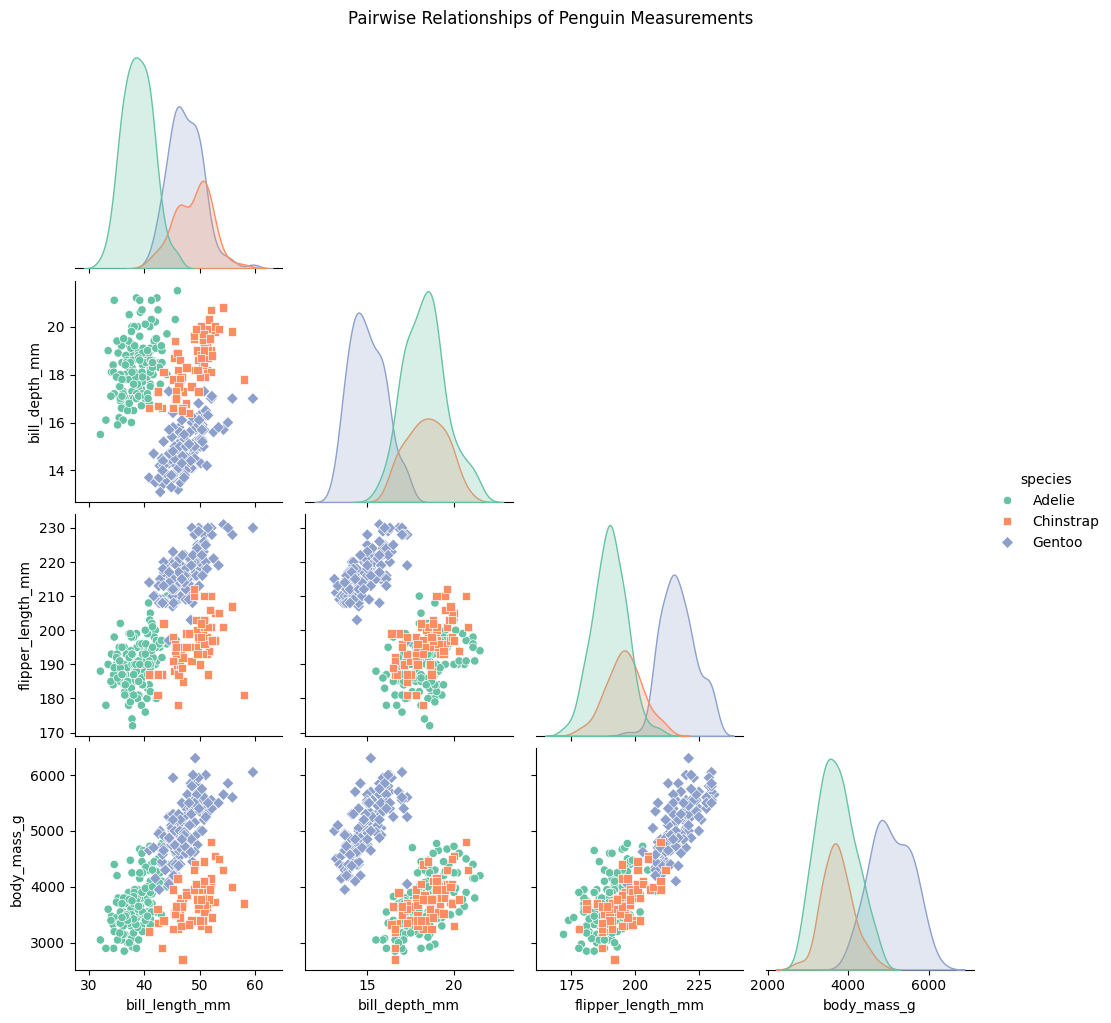

In [70]:
# Use Seaborn’s pairplot to visualize pairwise relationships in the dataset. Adding hue by specie.

sns.pairplot(
    df,
    vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
    hue='species',
    corner=True,
    palette={'Adelie':'#66c2a5','Chinstrap':'#fc8d62','Gentoo':'#8da0cb'},
    diag_kind='kde',
    markers=["o", "s", "D"]
)

plt.suptitle("Pairwise Relationships of Penguin Measurements", y=1.02)
plt.show()


Gentoo is clearly separated in body mass and flipper length.

Adelie and Chinstrap have more similar values, especially in bill measurements.

This confirms that many of the bimodal distributions you saw earlier are due to species, not sex.

#Palmer Penguins Mini-Project Dataset

Penguin dataset from the Palmer Archipelago, analizyng 3 species: Adélie, Gentoo, Chinstrap.

Key variables: body measurements (flipper length, body mass, bill length/depth), sex, island.


##Missing Values ​​& Data Cleaning

Dataset  fairly clean: only 11 missing values ​​for sex and 2 for each of the numerical variables.

These were replaced by the mode (sex) or median (numerical measurements), to ensure not bias.


##Key Insights

**Species is the strongest structural driver in the dataset.**

**Species Distribution**

Adélie is slightly dominant in number of records.

The species are distributed differently depending on the island. Each species seems to have its preferred island, likely due to food availability or habitat:

- Biscoe: 26% Adelie, 74% Gentoo

- Dream: 45% Adelie, 55% Chinstrap

- Torgersen: 100% Adelie

**Sexual Dimorphism**

Males are larger than females in all species.

These differences are most pronounced in Gentoo.

**Relationship Between Measurements**

Differences in bill length/depth help distinguish Adelie from Chinstrap.

Both histograms and pairplots confirm that the bimodal/multimodal separation is primarily due to species, not sex.

**Correlations**

Flipper length and body mass show a strong positive correlation.